# Geo-Based Incrementality Testing, Luma Candle Co.
**Author:** Justin  
**Date:** 2025  
**Repo:** MarketingScience / geo-incrementality 

---

Luma Candle Co. ran a 5-week regional promotion (20% discount, March 2025) across 5 Southeast and Mid-Atlantic DMAs. This notebook estimates the true incremental revenue lift using five methods, from a naive pre/post baseline up to a full Bayesian geolift model, and compares them against the known ground truth baked into the synthetic dataset.

---
## Section 1: Data Creation & Saving

We simulate 78 weeks of weekly DMA-level revenue across 12 markets (5 treated, 7 control). The dataset includes realistic trend, seasonality, and noise. A **+22% incremental lift** is baked into treated DMAs during the 5-week promo window. This is our ground truth to recover.

**Key design choices:**
- 14-month pre-period gives methods enough runway to establish parallel trends
- Control markets are geographically distinct (Midwest) to avoid spillover
- Small post-promo hangover (+4%) reflects realistic demand pull-forward

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── DMA configuration ──────────────────────────────────────────────────
dmas = {
    # Treated — Southeast + Mid-Atlantic
    'Atlanta, GA':       {'treated': True,  'base': 48000, 'trend': 0.008, 'noise': 0.06},
    'Charlotte, NC':     {'treated': True,  'base': 31000, 'trend': 0.006, 'noise': 0.07},
    'Richmond, VA':      {'treated': True,  'base': 22000, 'trend': 0.005, 'noise': 0.08},
    'Nashville, TN':     {'treated': True,  'base': 35000, 'trend': 0.009, 'noise': 0.06},
    'Baltimore, MD':     {'treated': True,  'base': 29000, 'trend': 0.007, 'noise': 0.07},
    # Control — Midwest
    'Columbus, OH':      {'treated': False, 'base': 27000, 'trend': 0.006, 'noise': 0.07},
    'Indianapolis, IN':  {'treated': False, 'base': 24000, 'trend': 0.005, 'noise': 0.08},
    'Kansas City, MO':   {'treated': False, 'base': 21000, 'trend': 0.004, 'noise': 0.07},
    'Louisville, KY':    {'treated': False, 'base': 18000, 'trend': 0.006, 'noise': 0.09},
    'Memphis, TN':       {'treated': False, 'base': 20000, 'trend': 0.005, 'noise': 0.08},
    'Oklahoma City, OK': {'treated': False, 'base': 16000, 'trend': 0.004, 'noise': 0.09},
    'St. Louis, MO':     {'treated': False, 'base': 23000, 'trend': 0.007, 'noise': 0.07},
}

PROMO_LIFT  = 0.22
PROMO_DECAY = 0.04

weeks       = pd.date_range('2024-01-01', periods=78, freq='W-MON')
promo_start = pd.Timestamp('2025-03-03')
promo_end   = pd.Timestamp('2025-03-31')

# ── Generate rows ───────────────────────────────────────────────────────
rows = []
for dma, cfg in dmas.items():
    for i, week in enumerate(weeks):
        trend_factor = (1 + cfg['trend']) ** i
        noise        = np.random.normal(1.0, cfg['noise'])
        base_rev     = cfg['base'] * trend_factor * noise

        month    = week.month
        seasonal = {11: 1.18, 12: 1.32, 1: 0.88, 2: 0.92}.get(month, 1.0)

        in_promo   = cfg['treated'] and (promo_start <= week <= promo_end)
        post_promo = cfg['treated'] and (promo_end < week <= promo_end + pd.Timedelta(weeks=3))
        promo_effect = PROMO_LIFT if in_promo else (PROMO_DECAY if post_promo else 0.0)

        rows.append({
            'week':      week,
            'dma':       dma,
            'treated':   cfg['treated'],
            'in_promo':  in_promo,
            'revenue':   round(base_rev * seasonal * (1 + promo_effect), 2),
        })

df = pd.DataFrame(rows)
df.to_csv('../data/luma_geo_data.csv', index=False)
print(f'Saved: {df.shape[0]} rows | {df.dma.nunique()} DMAs | {df.week.nunique()} weeks')
print(f'Promo window: {promo_start.date()} — {promo_end.date()} ({df.in_promo.sum()} treated-market rows)')
df.head()

Saved: 936 rows | 12 DMAs | 78 weeks
Promo window: 2025-03-03 — 2025-03-31 (25 treated-market rows)


,week,dma,treated,in_promo,revenue
0,2024-01-01,"Atlanta, GA",True,False,43498.87
1,2024-01-08,"Atlanta, GA",True,False,42224.70
2,2024-01-15,"Atlanta, GA",True,False,44586.41
3,2024-01-22,"Atlanta, GA",True,False,47215.24
4,2024-01-29,"Atlanta, GA",True,False,42995.33


***Notes:***

The experiment has already been set up and run, we are simply running the analysis. Dataset is simple, weekly DMA-level data for treated & untreated locations for pre and post promotional timeline, with total revenue for measurement. I am aware that there is a lot of work done before this point, including setting up the experiment, collecting the data, cleaning the data, and preparing it for this analysis. I am planning on doing another project eventually do show how to set up geo tests. This analysis is focusing on the analysis and results

---
## Section 2: Data Alignment

Before any modeling, we reshape and validate the data. Each method needs a slightly different format, so we prepare the key views here once and reuse them throughout:

- **`df_long`** tidy panel format (one row per DMA per week), used for DiD
- **`df_wide`** DMAs as columns, weeks as index, used for Synthetic Control, CausalImpact, and Geolift
- **`df_agg`** treated vs. control aggregate weekly totals, used for naive and quick plots

We also confirm parallel trends visually in the pre-period, a required assumption for DiD.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── DMA configuration ──────────────────────────────────────────────────
dmas = {
    # Treated — Southeast + Mid-Atlantic
    'Atlanta, GA':       {'treated': True,  'base': 48000, 'trend': 0.008, 'noise': 0.06},
    'Charlotte, NC':     {'treated': True,  'base': 31000, 'trend': 0.006, 'noise': 0.07},
    'Richmond, VA':      {'treated': True,  'base': 22000, 'trend': 0.005, 'noise': 0.08},
    'Nashville, TN':     {'treated': True,  'base': 35000, 'trend': 0.009, 'noise': 0.06},
    'Baltimore, MD':     {'treated': True,  'base': 29000, 'trend': 0.007, 'noise': 0.07},
    # Control — Midwest
    'Columbus, OH':      {'treated': False, 'base': 27000, 'trend': 0.006, 'noise': 0.07},
    'Indianapolis, IN':  {'treated': False, 'base': 24000, 'trend': 0.005, 'noise': 0.08},
    'Kansas City, MO':   {'treated': False, 'base': 21000, 'trend': 0.004, 'noise': 0.07},
    'Louisville, KY':    {'treated': False, 'base': 18000, 'trend': 0.006, 'noise': 0.09},
    'Memphis, TN':       {'treated': False, 'base': 20000, 'trend': 0.005, 'noise': 0.08},
    'Oklahoma City, OK': {'treated': False, 'base': 16000, 'trend': 0.004, 'noise': 0.09},
    'St. Louis, MO':     {'treated': False, 'base': 23000, 'trend': 0.007, 'noise': 0.07},
}

PROMO_LIFT  = 0.22
PROMO_DECAY = 0.04

weeks       = pd.date_range('2024-01-01', periods=78, freq='W-MON')
promo_start = pd.Timestamp('2025-03-03')
promo_end   = pd.Timestamp('2025-03-31')

# ── Reload from saved CSV (clean entry point for modeling) ──────────────
df = pd.read_csv('../data/luma_geo_data.csv', parse_dates=['week'])

# ── Format 1: tidy panel (DiD) ──────────────────────────────────────────
df_long = df.copy()
df_long['post'] = (df_long['week'] >= promo_start).astype(int)
df_long['treated_int'] = df_long['treated'].astype(int)
df_long['did_interaction'] = df_long['post'] * df_long['treated_int']

# ── Format 2: wide (SC / CausalImpact / Geolift) ────────────────────────
df_wide = df.pivot(index='week', columns='dma', values='revenue')
df_wide.index.name = 'week'

treated_dmas = [d for d, c in dmas.items() if c['treated']]
control_dmas = [d for d, c in dmas.items() if not c['treated']]

# ── Format 3: aggregated treated vs control ──────────────────────────────
df_agg = (
    df.groupby(['week', 'treated'])['revenue']
    .sum()
    .reset_index()
    .pivot(index='week', columns='treated', values='revenue')
    .rename(columns={True: 'treated_total', False: 'control_total'})
)

print('df_long shape: ', df_long.shape)
print('df_wide shape: ', df_wide.shape)
print('df_agg shape:  ', df_agg.shape)
print('\nTreated DMAs: ', treated_dmas)
print('Control DMAs: ', control_dmas)

df_long shape:  (936, 8)
df_wide shape:  (78, 12)
df_agg shape:   (78, 2)

Treated DMAs:  ['Atlanta, GA', 'Charlotte, NC', 'Richmond, VA', 'Nashville, TN', 'Baltimore, MD']
Control DMAs:  ['Columbus, OH', 'Indianapolis, IN', 'Kansas City, MO', 'Louisville, KY', 'Memphis, TN', 'Oklahoma City, OK', 'St. Louis, MO']


In [2]:
df.head()

,week,dma,treated,in_promo,revenue
0,2024-01-01,"Atlanta, GA",True,False,43498.87
1,2024-01-08,"Atlanta, GA",True,False,42224.70
2,2024-01-15,"Atlanta, GA",True,False,44586.41
3,2024-01-22,"Atlanta, GA",True,False,47215.24
4,2024-01-29,"Atlanta, GA",True,False,42995.33


In [3]:
df_long.head()

,week,dma,treated,in_promo,revenue,post,treated_int,did_interaction
0,2024-01-01,"Atlanta, GA",True,False,43498.87,0,1,0
1,2024-01-08,"Atlanta, GA",True,False,42224.70,0,1,0
2,2024-01-15,"Atlanta, GA",True,False,44586.41,0,1,0
3,2024-01-22,"Atlanta, GA",True,False,47215.24,0,1,0
4,2024-01-29,"Atlanta, GA",True,False,42995.33,0,1,0


In [4]:
df_wide.head()

dma,"Atlanta, GA","Baltimore, MD","Charlotte, NC","Columbus, OH","Indianapolis, IN","Kansas City, MO","Louisville, KY","Memphis, TN","Nashville, TN","Oklahoma City, OK","Richmond, VA","St. Louis, MO"
week,,,,,,,,,,,,
2024-01-01,43498.87,26994.52,27455.23,22265.76,20223.67,19226.50,18111.25,16608.28,34762.01,14305.18,22249.71,19457.61
2024-01-08,42224.70,27162.07,23625.45,24725.63,20247.83,18290.21,15201.88,15694.97,32259.23,12437.40,20194.34,21284.69
2024-01-15,44586.41,28243.40,27183.81,21823.73,20862.34,19112.10,14602.89,15562.73,27546.76,14678.51,17690.50,20815.89
2024-01-22,47215.24,26097.99,28468.28,27291.49,17490.43,17911.92,15944.27,18731.45,31993.06,15032.69,20684.05,18475.10
2024-01-29,42995.33,27494.81,30831.17,26344.54,18933.93,18891.27,16304.96,16115.48,30656.25,15027.42,18210.11,23067.24


In [5]:
df_agg.head()

treated,control_total,treated_total
week,,
2024-01-01,130198.25,154960.34
2024-01-08,127882.61,145465.79
2024-01-15,127458.19,145250.88
2024-01-22,130877.35,154458.62
2024-01-29,134684.84,150187.67


***Notes:***

Created three different data views here to analyze our results using several methodologies. All pretty straight forward.

---
## Section 3: Exploratory Data Analysis

Three quick plots before any modeling:

1. **Aggregate revenue over time**: treated vs. control, with promo window shaded
2. **Per-DMA revenue**: check for any rogue markets or obvious outliers
3. **Pre-period parallel trends check**: visually confirm treated and control move together before the promo

The parallel trends assumption is the load-bearing wall for DiD. If it breaks here, DiD results are unreliable.

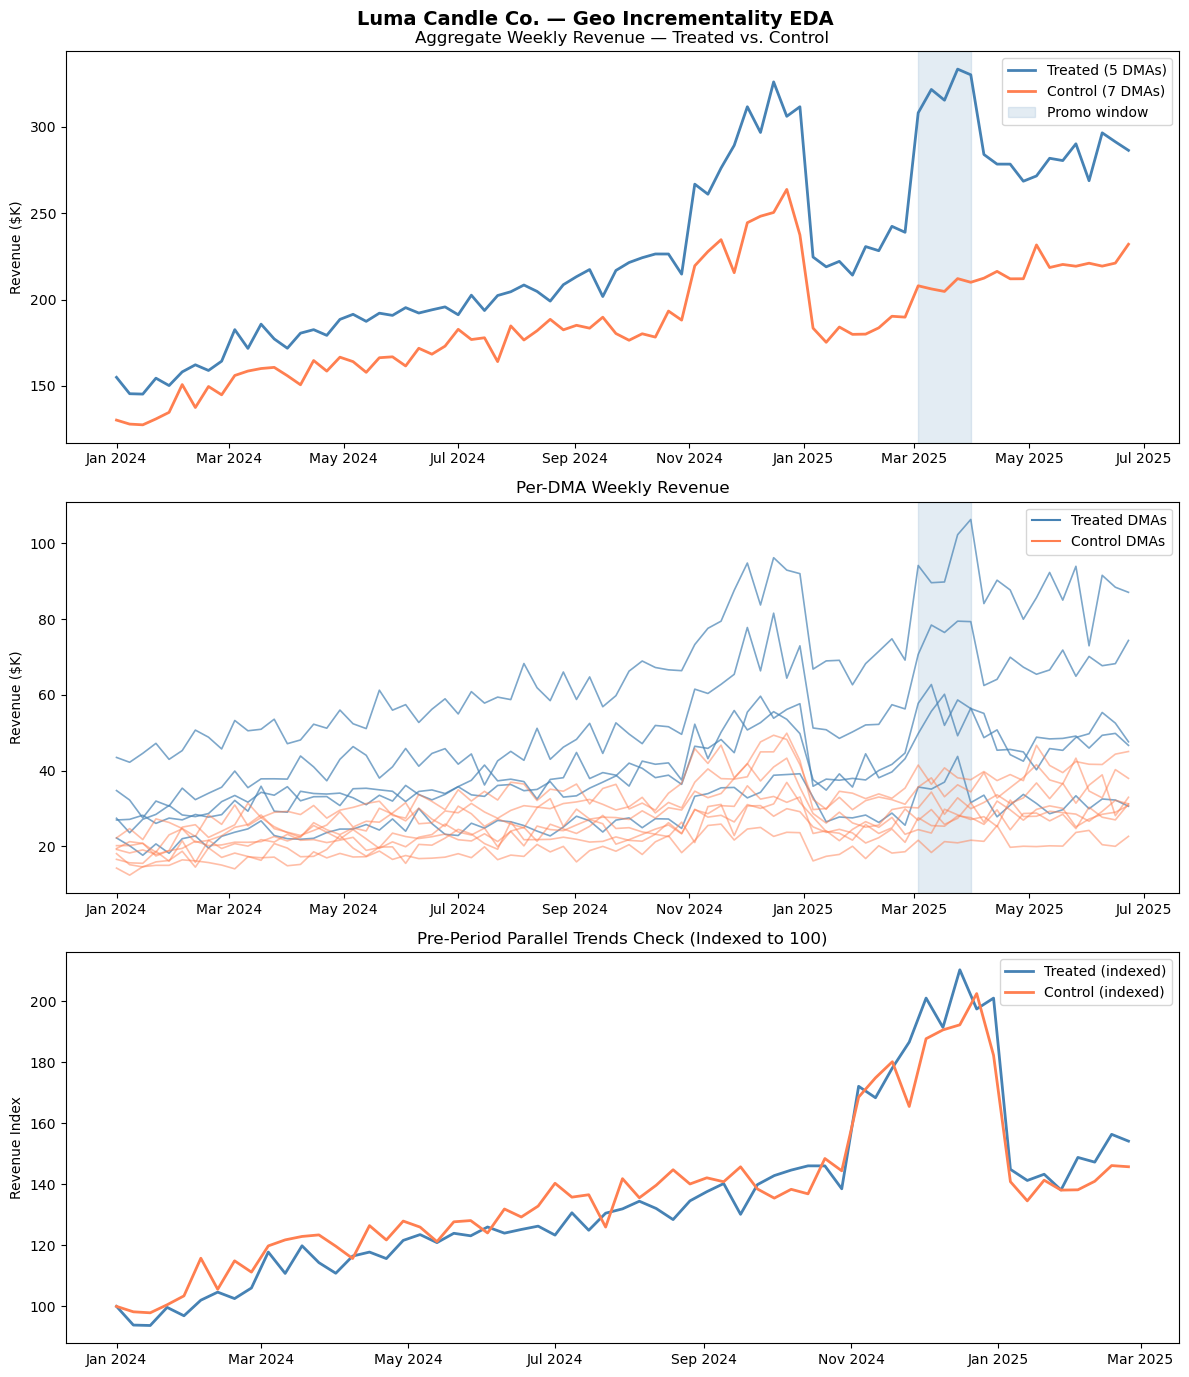

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle('Luma Candle Co. — Geo Incrementality EDA', fontsize=14, fontweight='bold', y=0.98)

promo_kw = dict(alpha=0.15, color='steelblue')

# ── Plot 1: Aggregate treated vs control ────────────────────────────────
ax = axes[0]
ax.plot(df_agg.index, df_agg['treated_total'] / 1e3, label='Treated (5 DMAs)', color='steelblue', lw=2)
ax.plot(df_agg.index, df_agg['control_total'] / 1e3, label='Control (7 DMAs)', color='coral', lw=2)
ax.axvspan(promo_start, promo_end, **promo_kw, label='Promo window')
ax.set_title('Aggregate Weekly Revenue — Treated vs. Control')
ax.set_ylabel('Revenue ($K)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# ── Plot 2: Per-DMA revenue ──────────────────────────────────────────────
ax = axes[1]
for dma in treated_dmas:
    ax.plot(df_wide.index, df_wide[dma] / 1e3, color='steelblue', lw=1.2, alpha=0.7)
for dma in control_dmas:
    ax.plot(df_wide.index, df_wide[dma] / 1e3, color='coral', lw=1.2, alpha=0.5)
ax.axvspan(promo_start, promo_end, **promo_kw)
ax.plot([], [], color='steelblue', label='Treated DMAs')
ax.plot([], [], color='coral', label='Control DMAs')
ax.set_title('Per-DMA Weekly Revenue')
ax.set_ylabel('Revenue ($K)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# ── Plot 3: Pre-period parallel trends ──────────────────────────────────
ax = axes[2]
pre = df_agg[df_agg.index < promo_start].copy()
# Normalize to index = 100 at start so we compare trends, not levels
pre_t = (pre['treated_total'] / pre['treated_total'].iloc[0]) * 100
pre_c = (pre['control_total'] / pre['control_total'].iloc[0]) * 100
ax.plot(pre.index, pre_t, label='Treated (indexed)', color='steelblue', lw=2)
ax.plot(pre.index, pre_c, label='Control (indexed)', color='coral', lw=2)
ax.set_title('Pre-Period Parallel Trends Check (Indexed to 100)')
ax.set_ylabel('Revenue Index')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('../outputs/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

***Notes:***

Graph 1: There appears to be this obvious jump in revenue during the promo window for the treated group.

Graph 2: I don't see any markets that I would consider to be outliers or outrageous to the point of dropping.

Graph 3: I would consider these trends to be parallel. We could also run a pre-period regression, a placebo/falsification test, and/or a correlation of pre-period trends, none of which I am going to run here, but would 100% run if this were real.

---
## Section 4: Naive Pre/Post Estimate

The simplest possible baseline: compare average weekly revenue in treated markets during the promo window to the same markets in the equivalent weeks one year prior. **No counterfactual. No control group.**

This is what a channel analyst typically reports. The whole point of running this first is to quantify the bias, how much does a naive read overcount the true lift?

**Known ground truth: +22% lift. Watch how far off this lands.**

In [7]:
# ── Pre-period: same 5 weeks, one year prior ────────────────────────────
prior_start = promo_start - pd.DateOffset(years=1)
prior_end   = promo_end   - pd.DateOffset(years=1)

treated_df = df[df['treated'] == True]

pre_avg  = treated_df[(treated_df['week'] >= prior_start) & (treated_df['week'] <= prior_end)]['revenue'].mean()
post_avg = treated_df[(treated_df['week'] >= promo_start) & (treated_df['week'] <= promo_end)]['revenue'].mean()

naive_lift_pct = (post_avg - pre_avg) / pre_avg * 100
naive_lift_abs = post_avg - pre_avg

print('=' * 45)
print('NAIVE PRE/POST ESTIMATE')
print('=' * 45)
print(f'Pre-period avg weekly revenue (treated):  ${pre_avg:>10,.0f}')
print(f'During-promo avg weekly revenue (treated): ${post_avg:>10,.0f}')
print(f'Naive lift (absolute):                    ${naive_lift_abs:>10,.0f} / market / week')
print(f'Naive lift (%):                            {naive_lift_pct:>9.1f}%')
print(f'Ground truth:                              {22.0:>9.1f}%')
print(f'Overcount:                                 {naive_lift_pct - 22.0:>+9.1f}%')

NAIVE PRE/POST ESTIMATE
Pre-period avg weekly revenue (treated):  $    35,860
During-promo avg weekly revenue (treated): $    64,343
Naive lift (absolute):                    $    28,483 / market / week
Naive lift (%):                                 79.4%
Ground truth:                                   22.0%
Overcount:                                     +57.4%


***Notes:***

Pre-period average weekly revenue sits at about $35k for the treatment group and promo revenue at about $64k. This gives us a $28k/market/week lift, a 79% lift. We know the actual lift, 22%, which means we overcounted by 57 percentage points. This would have given our business too much confidence in this promo 

---
## Section 5: Difference-in-Differences (CausalPy)

DiD compares the *change* in treated markets to the *change* in control markets over the same period. By subtracting out what the control group did, we remove shared confounders like seasonality and macro trend.

**The estimand:** the Average Treatment Effect on the Treated (ATT), how much did revenue increase in treated markets *because of* the promo, above and beyond what would have happened anyway?

**Key assumption:** parallel trends: in the absence of the promo, treated and control markets would have evolved similarly. We validated this visually in Section 3.

We use CausalPy's PyMC-backed DiD, which gives us a full posterior over the treatment effect instead of a point estimate + frequentist p-value.

In [8]:
import causalpy as cp

# ── Prep: restrict to promo window + same weeks in pre-period ────────────
# DiD needs a clean pre and post period — use 8 weeks pre, 5 weeks during promo
pre_start_did = promo_start - pd.Timedelta(weeks=8)

df_did = df_long[
    (df_long['week'] >= pre_start_did) &
    (df_long['week'] <= promo_end)
].copy()

df_did['unit'] = df_did['dma']  # For DiD, each DMA is a unit observed over time

print(f'DiD window: {pre_start_did.date()} to {promo_end.date()}')
print(f'Rows: {len(df_did)} | Pre rows: {(df_did.post==0).sum()} | Post rows: {(df_did.post==1).sum()}')

DiD window: 2025-01-06 to 2025-03-31
Rows: 156 | Pre rows: 96 | Post rows: 60


In [ ]:
# Reminder of variable names as they can be persnickety in CausalPy DiD setup:
df_did.head()

,week,dma,treated,in_promo,revenue,post,treated_int,did_interaction,unit
53,2025-01-06,"Atlanta, GA",True,False,66801.38,0,1,0,"Atlanta, GA"
54,2025-01-13,"Atlanta, GA",True,False,68969.95,0,1,0,"Atlanta, GA"
55,2025-01-20,"Atlanta, GA",True,False,69129.98,0,1,0,"Atlanta, GA"
56,2025-01-27,"Atlanta, GA",True,False,62672.34,0,1,0,"Atlanta, GA"
57,2025-02-03,"Atlanta, GA",True,False,68256.87,0,1,0,"Atlanta, GA"


In [16]:
# ── Fit DiD model ────────────────────────────────────────────────────────
did_model = cp.DifferenceInDifferences(
    data=df_did,
    formula='revenue ~ 1 + treated_int + post + treated_int*post',
    time_variable_name='post',
    group_variable_name='treated_int',
    post_treatment_variable_name='post',
    model=cp.pymc_models.LinearRegression(
        sample_kwargs={
            # 'draws': 1000, 
            # 'chains': 2, 
            'target_accept': 0.9
        }
    ),
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 23 seconds.
Sampling: [beta, y_hat, y_hat_sigma]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


In [17]:
did_model.summary()

===========================Difference in Differences============================
Formula: revenue ~ 1 + treated_int + post + treated_int*post

Results:
Causal impact = 5911.17$CI_{94\%}$[5826, 5996]
Model coefficients:
    Intercept         18996, 94% HDI [18929, 19063]
    treated_int       12653, 94% HDI [12572, 12736]
    post              7355, 94% HDI [7278, 7436]
    treated_int:post  5911, 94% HDI [5826, 5996]
    y_hat_sigma       453, 94% HDI [452, 454]


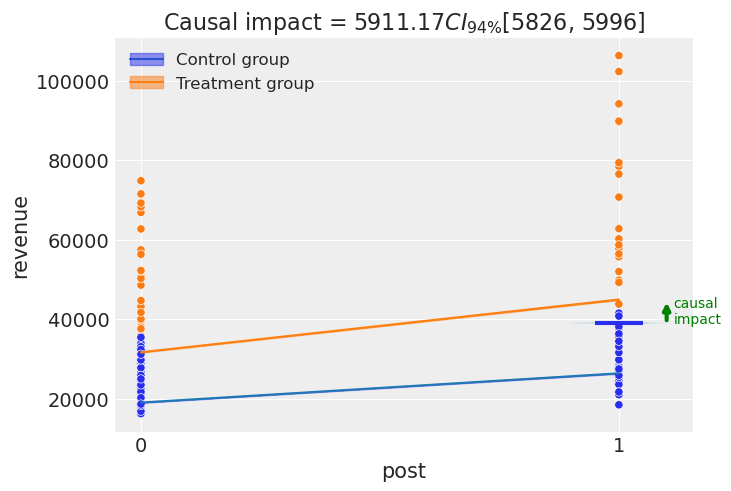

In [18]:
# ── Plot DiD results ─────────────────────────────────────────────────────
fig, ax = did_model.plot()

In [22]:
idata_did = did_model.idata

# Find the index for the interaction term inside the 'coeffs' dimension
coeffs_labels = idata_did.posterior['coeffs'].values
interaction_idx = list(coeffs_labels).index('treated_int:post')

print('Available coefficients:', list(coeffs_labels))
print('Interaction term index:', interaction_idx)

# Extract beta for that coefficient, squeeze out the singleton treated_units dim
att_samples = idata_did.posterior['beta'].isel(coeffs=interaction_idx, treated_units=0).values.flatten()

att_mean = att_samples.mean()
att_hdi_lo, att_hdi_hi = np.percentile(att_samples, [2.5, 97.5])

pre_avg_treated = df_did[(df_did['post']==0) & (df_did['treated_int']==1)]['revenue'].mean()
att_pct = att_mean / pre_avg_treated * 100

print('=' * 45)
print('DiD ESTIMATE (Bayesian)')
print('=' * 45)
print(f'ATT (absolute, $/market/week):  ${att_mean:>10,.0f}')
print(f'95% credible interval:          ${att_hdi_lo:>10,.0f} — ${att_hdi_hi:,.0f}')
print(f'ATT (%):                         {att_pct:>9.1f}%')
print(f'Ground truth:                    {22.0:>9.1f}%')

Available coefficients: [np.str_('Intercept'), np.str_('treated_int'), np.str_('post'), np.str_('treated_int:post')]
Interaction term index: 3
DiD ESTIMATE (Bayesian)
ATT (absolute, $/market/week):  $     5,911
95% credible interval:          $     5,824 — $6,000
ATT (%):                              13.0%
Ground truth:                         22.0%


***Notes:***

The 95% credible interval is tight here, we are seeing a much lower 13% lift compared to the 79% lift we saw using the naive method. Given we are looking to get as close as we can to 22%, this is fairly accurate. The promo increases weekly revenue for each market by $5,911, or 13%. 

---
## Section 6: Synthetic Control (CausalPy)

Synthetic Control builds a weighted combination of control markets that best approximates a treated market's pre-period trajectory. That synthetic market becomes the counterfactual: what Atlanta (or the average treated market) *would have done* without the promo.

The gap between actual and synthetic in the post period is the estimated lift.

**Why this is compelling for a deck:** the chart is self-explanatory. A non-technical stakeholder can look at 'actual vs. synthetic' and immediately understand what a counterfactual means.

**No parallel trends assumption required** — the pre-period fit does that work instead.

We run it on aggregate treated revenue (all 5 DMAs summed) vs. the control pool.

In [14]:
# ── Prep: wide format, pre/post split ───────────────────────────────────
# Aggregate all treated DMAs into one series
treated_agg = df_wide[treated_dmas].sum(axis=1).rename('Treated_Aggregate')
sc_df = pd.concat([df_wide[control_dmas], treated_agg], axis=1).reset_index()

print(f'Synthetic Control dataset: {sc_df.shape}')
sc_df.head()

Synthetic Control dataset: (78, 9)


,week,"Columbus, OH","Indianapolis, IN","Kansas City, MO","Louisville, KY","Memphis, TN","Oklahoma City, OK","St. Louis, MO",Treated_Aggregate
0,2024-01-01,22265.76,20223.67,19226.50,18111.25,16608.28,14305.18,19457.61,154960.34
1,2024-01-08,24725.63,20247.83,18290.21,15201.88,15694.97,12437.40,21284.69,145465.79
2,2024-01-15,21823.73,20862.34,19112.10,14602.89,15562.73,14678.51,20815.89,145250.88
3,2024-01-22,27291.49,17490.43,17911.92,15944.27,18731.45,15032.69,18475.10,154458.62
4,2024-01-29,26344.54,18933.93,18891.27,16304.96,16115.48,15027.42,23067.24,150187.67


In [15]:
# ── Fit Synthetic Control ────────────────────────────────────────────────
sc_model = cp.SyntheticControl(
    data=sc_df,
    treatment_time=promo_start,
    formula='Treated_Aggregate ~ ' + ' + '.join([f'`{c}`' for c in control_dmas]),
    model=cp.pymc_models.WeightedSumFitted(
        sample_kwargs={'draws': 1000, 'chains': 2, 'target_accept': 0.9}
    ),
)

sc_model.summary()

AttributeError: module 'causalpy.pymc_models' has no attribute 'WeightedSumFitted'

In [ ]:
# ── Extract lift estimate ────────────────────────────────────────────────
sc_post = sc_df[sc_df['week'] >= promo_start].copy()
sc_pred = sc_model.idata.posterior_predictive  # posterior predictive for post period

# Point estimate: mean of posterior predictive vs actual
synth_mean = sc_pred['Treated_Aggregate'].mean(dim=['chain', 'draw']).values
actual_post = sc_post['Treated_Aggregate'].values

abs_lift_per_week = (actual_post - synth_mean).mean()
pct_lift = abs_lift_per_week / synth_mean.mean() * 100

print('=' * 45)
print('SYNTHETIC CONTROL ESTIMATE')
print('=' * 45)
print(f'Avg weekly actual (post):     ${actual_post.mean():>12,.0f}')
print(f'Avg weekly synthetic (post):  ${synth_mean.mean():>12,.0f}')
print(f'Estimated lift (%):            {pct_lift:>11.1f}%')
print(f'Ground truth:                  {22.0:>11.1f}%')

In [ ]:
# ── Plot: actual vs synthetic ────────────────────────────────────────────
sc_model.plot()
plt.suptitle('Luma Candle Co. — Synthetic Control: Actual vs. Counterfactual', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/synthetic_control.png', dpi=150, bbox_inches='tight')
plt.show()

***Notes:***

*[your notes here]*

---
## Section 7: CausalImpact (Bayesian Structural Time Series)

CausalImpact fits a Bayesian structural time series model using control market revenues as covariates. It learns how the treated market moved relative to controls in the pre-period, then projects that relationship forward as the counterfactual.

**What it adds over DiD and SC:** a full time-varying posterior — you get a credible interval on each week's lift, not just an aggregate. This makes it easy to see ramp-up, peak, and decay.

We run it on one treated DMA (Atlanta, GA — the largest market) for clarity, then note what a multi-market version would require.

In [16]:
from causalimpact import CausalImpact

# ── Prep: Atlanta as target, control DMAs as covariates ─────────────────
ci_df = df_wide[['Atlanta, GA'] + control_dmas].copy()

pre_period  = [ci_df.index.min().strftime('%Y-%m-%d'), (promo_start - pd.Timedelta(weeks=1)).strftime('%Y-%m-%d')]
post_period = [promo_start.strftime('%Y-%m-%d'), promo_end.strftime('%Y-%m-%d')]

print(f'Pre period:  {pre_period}')
print(f'Post period: {post_period}')
print(f'Target: Atlanta, GA | Covariates: {len(control_dmas)} control DMAs')

Pre period:  ['2024-01-01', '2025-02-24']
Post period: ['2025-03-03', '2025-03-31']
Target: Atlanta, GA | Covariates: 7 control DMAs


In [17]:
# ── Fit CausalImpact ─────────────────────────────────────────────────────
ci = CausalImpact(ci_df, pre_period, post_period)
ci.run()
print(ci.summary())

AttributeError: module 'pandas.core.dtypes.common' has no attribute 'is_datetime_or_timedelta_dtype'

In [ ]:
# ── Pull key numbers ─────────────────────────────────────────────────────
summary = ci.summary_data
rel_effect     = summary.loc['average', 'rel_effect']
rel_effect_lo  = summary.loc['average', 'rel_effect_lower']
rel_effect_hi  = summary.loc['average', 'rel_effect_upper']

print('=' * 50)
print('CAUSALIMPACT ESTIMATE — Atlanta, GA')
print('=' * 50)
print(f'Estimated lift (%):      {rel_effect * 100:>8.1f}%')
print(f'95% credible interval:   {rel_effect_lo*100:.1f}% — {rel_effect_hi*100:.1f}%')
print(f'Ground truth:            {22.0:>8.1f}%')

In [ ]:
# ── Plot ─────────────────────────────────────────────────────────────────
ci.plot()
plt.suptitle('CausalImpact — Atlanta, GA (Luma Candle Co.)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/causalimpact_atlanta.png', dpi=150, bbox_inches='tight')
plt.show()

***Notes:***

*[your notes here]*

---
## Section 8: Bayesian Geolift (CausalPy)

CausalPy's Bayesian Geolift combines synthetic control with full Bayesian inference. It learns a weighted combination of control markets that tracks the treated aggregate in the pre-period, then propagates uncertainty through the counterfactual into a posterior over the treatment effect.

**What this adds over regular Synthetic Control:** credible intervals on the counterfactual itself, not just a point estimate. You can make statements like: 'we are 95% confident the promo drove between X% and Y% incremental lift.'

This is the most rigorous method in this notebook and the natural capstone. It also maps directly to how companies like Meta and Uber run geo experiments internally.

In [18]:
# ── Prep: CausalPy geolift expects wide format with a single target column
# and control columns, indexed by time
geolift_df = df_wide.copy()

# Aggregate treated DMAs
geolift_df['treated_total'] = geolift_df[treated_dmas].sum(axis=1)
geolift_df = geolift_df[control_dmas + ['treated_total']].reset_index()

print(f'Geolift dataset: {geolift_df.shape}')
geolift_df.head()

Geolift dataset: (78, 9)


dma,week,"Columbus, OH","Indianapolis, IN","Kansas City, MO","Louisville, KY","Memphis, TN","Oklahoma City, OK","St. Louis, MO",treated_total
0,2024-01-01,22265.76,20223.67,19226.50,18111.25,16608.28,14305.18,19457.61,154960.34
1,2024-01-08,24725.63,20247.83,18290.21,15201.88,15694.97,12437.40,21284.69,145465.79
2,2024-01-15,21823.73,20862.34,19112.10,14602.89,15562.73,14678.51,20815.89,145250.88
3,2024-01-22,27291.49,17490.43,17911.92,15944.27,18731.45,15032.69,18475.10,154458.62
4,2024-01-29,26344.54,18933.93,18891.27,16304.96,16115.48,15027.42,23067.24,150187.67


In [19]:
# ── Fit Bayesian Geolift ─────────────────────────────────────────────────
geolift_model = cp.GeoLift(
    data=geolift_df,
    treatment_time=promo_start,
    formula='treated_total ~ ' + ' + '.join([f'`{c}`' for c in control_dmas]),
    model=cp.pymc_models.WeightedSumFitted(
        sample_kwargs={'draws': 1000, 'chains': 2, 'target_accept': 0.9}
    ),
)

geolift_model.summary()

AttributeError: module 'causalpy' has no attribute 'GeoLift'

In [ ]:
# ── Extract posterior lift estimate ─────────────────────────────────────
gl_idata = geolift_model.idata

# Posterior predictive counterfactual vs actual
post_mask = geolift_df['week'] >= promo_start
actual_gl  = geolift_df.loc[post_mask, 'treated_total'].values
cf_samples = gl_idata.posterior_predictive['treated_total'].values  # shape: (chains, draws, time)

# Mean counterfactual per week
cf_mean = cf_samples.reshape(-1, cf_samples.shape[-1]).mean(axis=0)
cf_lo   = np.percentile(cf_samples.reshape(-1, cf_samples.shape[-1]), 2.5, axis=0)
cf_hi   = np.percentile(cf_samples.reshape(-1, cf_samples.shape[-1]), 97.5, axis=0)

lift_pct_mean = ((actual_gl - cf_mean) / cf_mean * 100).mean()
lift_pct_lo   = ((actual_gl - cf_hi)   / cf_hi   * 100).mean()
lift_pct_hi   = ((actual_gl - cf_lo)   / cf_lo   * 100).mean()

print('=' * 50)
print('BAYESIAN GEOLIFT ESTIMATE')
print('=' * 50)
print(f'Estimated lift (%):      {lift_pct_mean:>8.1f}%')
print(f'95% credible interval:   {lift_pct_lo:.1f}% — {lift_pct_hi:.1f}%')
print(f'Ground truth:            {22.0:>8.1f}%')

In [ ]:
# ── Plot ─────────────────────────────────────────────────────────────────
geolift_model.plot()
plt.suptitle('Bayesian Geolift — Luma Candle Co. (Treated Aggregate)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/bayesian_geolift.png', dpi=150, bbox_inches='tight')
plt.show()

***Notes:***

*[your notes here]*

---
## Section 9: Method Comparison & Summary

Consolidate all estimates in one place and plot them against ground truth. This is the 'punchline' slide for Megan's CMO deck.

In [ ]:
# ── Manually fill in your results after running sections 4-8 ─────────────
# Replace the placeholder values with your actual model outputs

results = {
    'Method':          ['Naive Pre/Post', 'DiD (CausalPy)', 'Synthetic Control', 'CausalImpact', 'Bayesian Geolift'],
    'Lift Estimate %': [naive_lift_pct,    att_pct,           pct_lift,            rel_effect*100,  lift_pct_mean],
    'Lower 95%':       [None,              att_hdi_lo / pre_avg_treated * 100, None, rel_effect_lo*100, lift_pct_lo],
    'Upper 95%':       [None,              att_hdi_hi / pre_avg_treated * 100, None, rel_effect_hi*100, lift_pct_hi],
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

In [ ]:
# ── Plot comparison ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

methods   = results_df['Method']
estimates = results_df['Lift Estimate %']
y_pos     = range(len(methods))

ax.barh(y_pos, estimates, color='steelblue', alpha=0.7, height=0.5)

# Error bars where available
for i, row in results_df.iterrows():
    if row['Lower 95%'] is not None:
        ax.errorbar(
            x=row['Lift Estimate %'],
            y=i,
            xerr=[[row['Lift Estimate %'] - row['Lower 95%']],
                  [row['Upper 95%'] - row['Lift Estimate %']]],
            fmt='none', color='navy', capsize=5, lw=2
        )

ax.axvline(22, color='red', linestyle='--', lw=1.5, label='Ground truth (22%)')
ax.set_yticks(y_pos)
ax.set_yticklabels(methods)
ax.set_xlabel('Estimated Lift (%)')
ax.set_title('Luma Candle Co. — Incrementality Estimates by Method', fontweight='bold')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

***Notes:***

*[your notes here]*